
# 03 — Factor Digging & Modeling Prep (Post-Qlib)
**Inline-first:** all diagnostics (NaN ratio, correlation, PCA, Rolling IC, Regime IC) are **shown inline** as tables and charts.  
**Only modeling artifacts are saved to disk:** `curated_features.csv` and `hull_model_ready.csv`.

**Flow**
1) Loader & minimal hygiene (no re-normalization)  
2) Phase A: Inline analytics (NaN ratio, correlation/redundancy, PCA, Rolling IC, Regime IC)  
3) Phase B: Model-ready export (curated)  
4) Phase C: Hull modeling prep (hybrid: top-IC factors + PCs)


In [79]:

from pathlib import Path
import pandas as pd
import numpy as np

# Candidate locations for the Qlib-processed features
CANDIDATE_PATHS = [
    Path("/mnt/data/selected_features.csv"),
    Path("../outputs/features/selected_features.csv"),
]

OUT_DIR = Path("../outputs/factor_plus")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Configs
ROLL_IC_WIN = 60
REGIME_WIN = 60
REGIME_LOW_Q = 0.33
REGIME_HIGH_Q = 0.67
ANALYZABLE_NA_THRESHOLD = 0.50
REDUNDANCY_RHO = 0.80
TOP_PC_COUNT = 8
TOP_IC_FACTOR_COUNT = 8
IC_TOP_K_PLOT = 5  # show top-K in IC plot
MODE = 'lean'   # 'lean' (top-IC + PCs) or 'full' (curated wide baseline)
TARGET_HORIZON = 1  # forward steps for returns used by IC

def _first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None

def load_post_qlib():
    p = _first_existing(CANDIDATE_PATHS)
    if p is None:
        raise FileNotFoundError(f"selected_features.csv not found in any of: {CANDIDATE_PATHS}")
    if p.suffix.lower() != ".csv":
        raise ValueError(f"Expecting a CSV file, got: {p}")
    df = pd.read_csv(p)
    print(f"Loaded selected features CSV: {p} | shape={df.shape}")
    if "returns" not in df.columns and "market_forward_excess_returns" in df.columns:
        df = df.rename(columns={"market_forward_excess_returns": "returns"})
    if "returns" not in df.columns:
        raise ValueError("Expected 'returns' (or 'market_forward_excess_returns').")
    if "date" in df.columns:
        try:
            df["date"] = pd.to_datetime(df["date"])
        except Exception:
            pass
    elif "date_id" in df.columns:
        df["date"] = pd.to_datetime("1990-01-01") + pd.to_timedelta(df["date_id"].astype(int), unit="D")
    if "instrument" not in df.columns:
        df["instrument"] = "SP500"
    return df

# Load
df = load_post_qlib()

# Minimal hygiene (no re-standardization)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)

sort_cols = [c for c in ["instrument", "date"] if c in df.columns]
if sort_cols:
    df = df.sort_values(sort_cols).reset_index(drop=True)

if "instrument" in df.columns:
    def _ffill_bfill(g):
        g[num_cols] = g[num_cols].ffill().bfill()
        return g
    df = df.groupby("instrument", group_keys=False).apply(_ffill_bfill)
else:
    df[num_cols] = df[num_cols].ffill().bfill()

# Very permissive clipping to prevent pathological spikes
clip_bound = 10
df[num_cols] = df[num_cols].clip(lower=-clip_bound, upper=clip_bound)

print("Hygiene complete. Example rows:")
display(df.head(3))


Loaded selected features CSV: ..\outputs\features\selected_features.csv | shape=(8990, 22)
Hygiene complete. Example rows:


,date,ROLL_STD_M1_W10,ZSCORE_M1_W120,ROLL_MAX_M1_W5,ROLL_STD_M1_W5,ROLL_STD_M1_W20,DIFF_M1_SUB_M2,MOM_M1_T20,MOM_M1_T5,ROLL_STD_M1_W60,...,TECH_MACD_M1,RATIO_M1_DIV_M3,MOM_S1_T20,ZSCORE_V1_W60,TECH_BB_POSITION_M1,TECH_ROC_S1_10,ROLL_MAX_M1_W120,ROLL_STD_V1_W60,returns,instrument
0,1990-01-01,0.12523,0.023528,1.639695,0.158613,0.192433,2.938627,-0.3968,-0.192268,0.407889,...,0.0,4.842739,-0.119023,7.616867,-0.615303,0.040034,1.639695,0.0,-0.003038,SP500
1,1990-01-02,0.12523,0.023528,1.639695,0.158613,0.192433,2.938627,-0.3968,-0.192268,0.407889,...,0.0,4.842739,-0.119023,7.616867,-0.615303,0.040034,1.639695,0.0,-0.009114,SP500
2,1990-01-03,0.12523,0.023528,1.639695,0.158613,0.192433,2.938627,-0.3968,-0.192268,0.407889,...,0.0,4.842739,-0.119023,7.616867,-0.615303,0.040034,1.639695,0.0,-0.010243,SP500



## Factor column detection
Prefer `feature_list.txt` from 02 if available; otherwise infer by excluding non-factor columns.


In [50]:

feature_list_path = Path("../outputs/features/feature_list.txt")
exclude = {"date", "returns", "instrument", "date_id"}

if feature_list_path.exists():
    with open(feature_list_path) as f:
        factor_cols = [ln.strip() for ln in f if ln.strip() and ln.strip() in df.columns]
    if not factor_cols:
        factor_cols = [c for c in df.columns if c not in exclude and df[c].dtype.kind in "fc"]
else:
    factor_cols = [c for c in df.columns if c not in exclude and df[c].dtype.kind in "fc"]

print(f"Detected {len(factor_cols)} factor columns (pre-filter).")


Detected 20 factor columns (pre-filter).


### NaN ratio
We show the NaN ratio per factor and select the **analyzable** subset (≤50% NaN).


In [52]:

import matplotlib.pyplot as plt

na_ratio = df[factor_cols].isna().mean().sort_values(ascending=False)
analyzable = na_ratio[na_ratio <= ANALYZABLE_NA_THRESHOLD].index.tolist()
sparse = na_ratio[na_ratio > ANALYZABLE_NA_THRESHOLD].index.tolist()

print(f"Analyzable (<= {ANALYZABLE_NA_THRESHOLD:.0%} NaN): {len(analyzable)}")
print(f"Sparse     (>  {ANALYZABLE_NA_THRESHOLD:.0%} NaN): {len(sparse)}")

# Show top 20 highest NaN ratios
print("Top 20 highest NaN ratios:")
display(na_ratio.head(20).round(3).to_frame("nan_ratio"))
# Analysis subset view
dfA = df[["date","returns","instrument"] + analyzable].copy()


Analyzable (<= 50% NaN): 20
Sparse     (>  50% NaN): 0
Top 20 highest NaN ratios:


,nan_ratio
ROLL_STD_M1_W10,0.0
ZSCORE_M1_W120,0.0
ROLL_MAX_M1_W120,0.0
TECH_ROC_S1_10,0.0
TECH_BB_POSITION_M1,0.0
ZSCORE_V1_W60,0.0
MOM_S1_T20,0.0
RATIO_M1_DIV_M3,0.0
TECH_MACD_M1,0.0
ROLL_STD_M1_W120,0.0


### Correlation & redundancy 
We compute Spearman correlation and list the most correlated pairs. Then we apply a simple greedy redundancy filter (|rho| ≥ 0.8).


In [53]:

import numpy as np
import pandas as pd

if len(analyzable) >= 2:
    corrA = dfA[analyzable].corr(method="spearman")

    # Show top correlated pairs (by absolute correlation)
    corr_pairs = []
    cols = corrA.columns.tolist()
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            corr_pairs.append((cols[i], cols[j], abs(corrA.iloc[i, j])))
    corr_pairs.sort(key=lambda x: x[2], reverse=True)
    print("Top 20 |rho| pairs:")
    display(pd.DataFrame(corr_pairs[:20], columns=["factor_1","factor_2","abs_rho"]).round(3))

    # Redundancy filter
    THRESH = REDUNDANCY_RHO
    keepA, discardA = [], []
    for col in corrA.columns:
        if not keepA:
            keepA.append(col); continue
        if any(abs(corrA.loc[col, k]) >= THRESH for k in keepA):
            discardA.append(col)
        else:
            keepA.append(col)
    print(f"[Analyzable] Redundancy → kept {len(keepA)}, discarded {len(discardA)} @ |rho|>={THRESH}")
    print("Kept (first 20):", keepA[:20])
else:
    keepA, discardA = analyzable, []
    print("Not enough analyzable factors for correlation/redundancy; skipping filter.")


Top 20 |rho| pairs:


,factor_1,factor_2,abs_rho
0,DIFF_M1_SUB_M2,ROLL_MAX_M1_W5,0.947
1,ROLL_MAX_M1_W120,ROLL_MAX_M1_W5,0.919
2,ZSCORE_V1_W60,ROLL_STD_V1_W60,0.889
3,ROLL_MAX_M1_W120,DIFF_M1_SUB_M2,0.866
4,DIFF_M1_SUB_M2,ROLL_STD_V1_W60,0.784
5,RATIO_M1_DIV_M3,DIFF_M1_SUB_M2,0.757
6,ZSCORE_V1_W60,DIFF_M1_SUB_M2,0.749
7,ROLL_MAX_M1_W5,ROLL_STD_V1_W60,0.748
8,ZSCORE_V1_W60,ROLL_MAX_M1_W5,0.720
9,RATIO_M1_DIV_M3,ROLL_MAX_M1_W5,0.715


[Analyzable] Redundancy → kept 17, discarded 3 @ |rho|>=0.8
Kept (first 20): ['ROLL_STD_M1_W10', 'ZSCORE_M1_W120', 'ROLL_MAX_M1_W120', 'TECH_ROC_S1_10', 'TECH_BB_POSITION_M1', 'ZSCORE_V1_W60', 'MOM_S1_T20', 'RATIO_M1_DIV_M3', 'TECH_MACD_M1', 'ROLL_STD_M1_W120', 'MOM_M1_T60', 'RATIO_M1_DIV_M2', 'ROLL_STD_M1_W60', 'MOM_M1_T5', 'MOM_M1_T20', 'ROLL_STD_M1_W20', 'ROLL_STD_M1_W5']


### PCA 
Top 20 explained-variance ratios and cumulative variance plot. We also show the top 20 PC1 loadings.


Top 20 explained-variance ratios:


,explained_variance_ratio
0,0.4485
1,0.1097
2,0.1077
3,0.0731
4,0.0672
5,0.0479
6,0.0456
7,0.0381
8,0.0278
9,0.0127



Top 20 factor loadings for PC1:


,PC1_loading
RATIO_M1_DIV_M2,0.1591
MOM_M1_T60,0.0883
TECH_BB_POSITION_M1,0.0526
MOM_M1_T20,0.0307
MOM_M1_T5,0.0184
ROLL_STD_V1_W60,0.0105
ROLL_STD_M1_W120,0.0093
ROLL_STD_M1_W10,0.0076
ROLL_STD_M1_W20,0.0072
MOM_S1_T20,0.0027


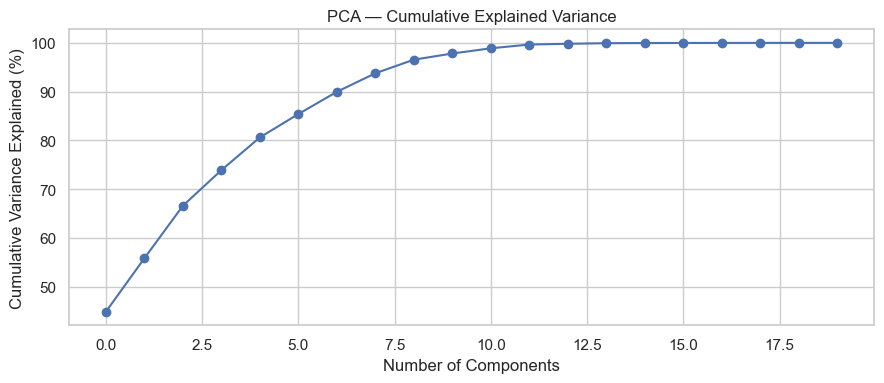

In [54]:

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if len(analyzable) >= 2:
    X = dfA[analyzable]
    X_filled = X.fillna(X.mean())  # mean-impute for PCA only

    pca = PCA()
    X_pca = pca.fit_transform(X_filled.values)
    evr = pd.Series(pca.explained_variance_ratio_, name="explained_variance_ratio")
    loadings = pd.DataFrame(pca.components_, columns=analyzable)

    print("Top 20 explained-variance ratios:")
    display(evr.head(20).round(4).to_frame("explained_variance_ratio"))

    print("\nTop 20 factor loadings for PC1:")
    display(loadings.iloc[0].sort_values(ascending=False).head(20).round(4).to_frame("PC1_loading"))

    plt.figure(figsize=(9, 4))
    plt.plot(np.cumsum(evr) * 100, marker="o")
    plt.title("PCA — Cumulative Explained Variance")
    plt.xlabel("Number of Components")
    plt.ylabel("Cumulative Variance Explained (%)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough analyzable factors for PCA.")


### Rolling IC 
- Sorted table of mean IC (top & bottom 10)
- Average IC over time (line chart)
- Rolling IC for top-K factors (line chart)


Top 10 by mean_IC (rolling, win=20, horizon=1):


,mean_IC,valid_points,valid_pct
factor,,,
ROLL_MAX_M1_W5,0.1698,3436,0.382
ZSCORE_M1_W120,0.1434,3321,0.369
TECH_BB_POSITION_M1,0.1038,3421,0.381
ROLL_STD_M1_W5,0.0702,3436,0.382
ROLL_STD_M1_W10,0.0692,3431,0.382
ROLL_MAX_M1_W120,0.0614,681,0.076
ROLL_STD_M1_W20,0.0339,3421,0.381
ROLL_STD_M1_W60,0.0251,3381,0.376
ROLL_STD_M1_W120,0.0237,3321,0.369



Bottom 10 by mean_IC (rolling):


,mean_IC,valid_points,valid_pct
factor,,,
MOM_S1_T20,0.0134,7961,0.886
DIFF_M1_SUB_M2,0.0045,3440,0.383
RATIO_M1_DIV_M2,0.0035,3440,0.383
ZSCORE_V1_W60,-0.0006,5197,0.578
ROLL_STD_V1_W60,-0.0039,5026,0.559
RATIO_M1_DIV_M3,-0.0222,3440,0.383
MOM_M1_T5,-0.0563,3435,0.382
MOM_M1_T60,-0.0667,3380,0.376
MOM_M1_T20,-0.0781,3420,0.380


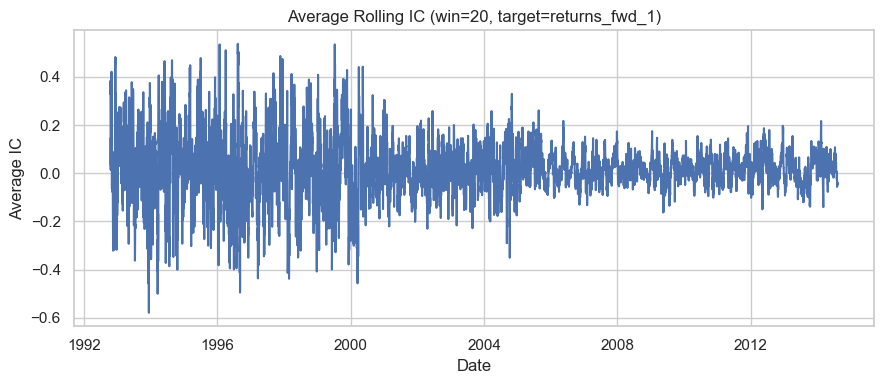

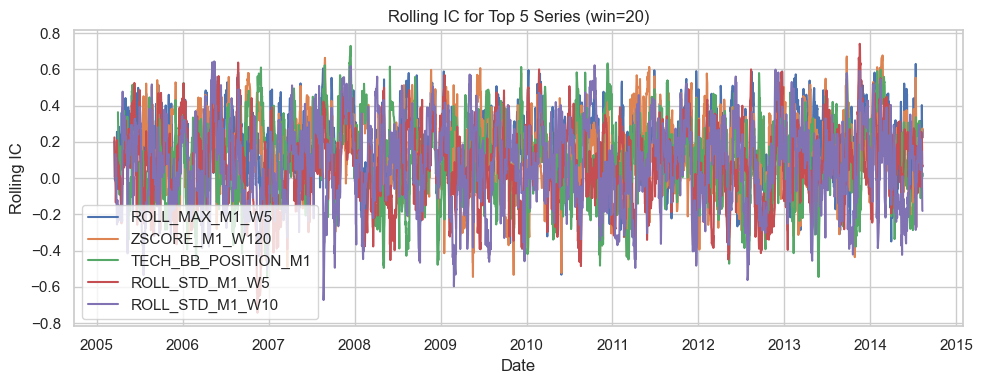

In [72]:
# === Rolling IC (robust, forward-returns, inline-only) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- knobs you can tweak ----------
WIN = 20                 # rolling window for IC (20–60 typical)
IC_TOP_K = 5             # how many series to plot
TARGET_HORIZON = 1       # forward steps for returns (1 = next period)
MIN_UNIQUE = 3           # min distinct ranks inside a window
USE_PCA_FOR_IC = False   # set True to evaluate IC on PCs instead of raw factors
# -----------------------------------------

# 0) ensure forward returns exist (shift -H)
dfA = dfA.sort_values("date").reset_index(drop=True).copy()
target_col = f"returns_fwd_{TARGET_HORIZON}"
if target_col not in dfA.columns:
    dfA[target_col] = dfA["returns"].shift(-TARGET_HORIZON)

# 1) time-series Spearman in rolling windows (single instrument)
def _ts_spearman_roll(x: pd.Series, y: pd.Series, win: int, min_unique: int = MIN_UNIQUE) -> pd.Series:
    # coerce numeric and rank (Spearman = Pearson on ranks)
    x = pd.to_numeric(x, errors="coerce")
    y = pd.to_numeric(y, errors="coerce")
    xr = x.rank(method="average")
    yr = y.rank(method="average")

    # rolling Pearson on ranks with min_periods
    r = xr.rolling(win, min_periods=max(10, win//2)).corr(yr)

    # kill windows with zero std or too few unique ranks (prevents ±inf/undefined)
    stdx = xr.rolling(win).std()
    stdy = yr.rolling(win).std()
    few_x = xr.rolling(win).apply(lambda s: s.nunique(dropna=True) < min_unique, raw=False).astype(bool)
    few_y = yr.rolling(win).apply(lambda s: s.nunique(dropna=True) < min_unique, raw=False).astype(bool)
    bad = (stdx == 0) | (stdy == 0) | few_x | few_y
    r[bad] = np.nan

    return r.replace([np.inf, -np.inf], np.nan).clip(-1, 1)

# 2) cross-sectional Spearman per date (multi-instrument)
def _cs_spearman_one_date(g: pd.DataFrame, factor: str, target: str) -> float:
    g2 = g[[factor, target]].dropna()
    if len(g2) < 3 or g2[factor].nunique() < 3 or g2[target].nunique() < 3:
        return np.nan
    return g2.corr(method="spearman").iloc[0, 1]

def compute_rolling_ic(df_in: pd.DataFrame, cols: list, target: str, win: int) -> pd.DataFrame:
    df_in = df_in.copy()
    sort_cols = [c for c in ["instrument", "date"] if c in df_in.columns]
    if sort_cols:
        df_in = df_in.sort_values(sort_cols).reset_index(drop=True)

    multi = ("instrument" in df_in.columns and df_in["instrument"].nunique() > 1)

    if multi:
        # daily cross-sectional IC, then smooth with rolling mean
        dates = sorted(df_in["date"].unique())
        daily = {c: [] for c in cols}
        for dt in dates:
            g = df_in[df_in["date"] == dt]
            for c in cols:
                daily[c].append(_cs_spearman_one_date(g, c, target))
        ic = pd.DataFrame(daily, index=pd.to_datetime(dates))
        ic = ic.rolling(win, min_periods=max(10, win//2)).mean()
    else:
        # single instrument: time-series IC
        df_ts = df_in.set_index("date")
        ic = pd.DataFrame(index=df_ts.index)
        for c in cols:
            ic[c] = _ts_spearman_roll(df_ts[c], df_ts[target], win=win)

    # sanitize
    ic = ic.apply(pd.to_numeric, errors="coerce").astype(float)
    ic = ic.replace([np.inf, -np.inf], np.nan).clip(-1, 1)
    return ic

# 3) choose which columns to evaluate
if USE_PCA_FOR_IC and "X_pca" in locals():
    # IC on top PCs (if PCA was computed earlier)
    pc_cols = [f"PC{i+1}" for i in range(min(TOP_PC_COUNT if 'TOP_PC_COUNT' in globals() else 8,
                                            X_pca.shape[1]))]
    df_ic_base = dfA.reset_index(drop=True).copy()
    df_ic_base = pd.concat([df_ic_base, pd.DataFrame(X_pca[:, :len(pc_cols)], columns=pc_cols)], axis=1)
    ic_cols = pc_cols
else:
    # IC on analyzable raw factors (or post-redundancy keepA if you prefer)
    ic_cols = analyzable[:] if 'analyzable' in globals() else [c for c in dfA.columns
                                                               if c not in {"date","instrument","returns",target_col}]
    df_ic_base = dfA.copy()

# 4) compute IC
if len(ic_cols) == 0:
    print("No columns available for IC. Check analyzable list or PCA toggle.")
else:
    ic_df = compute_rolling_ic(df_ic_base[["date","instrument",target_col] + ic_cols],
                               cols=ic_cols, target=target_col, win=WIN)

    # 5) robust summary (mean_IC + validity)
    stats = []
    n = len(ic_df.index)
    for c in ic_df.columns:
        v = ic_df[c].to_numpy(dtype=float)
        finite = np.isfinite(v)
        valid = int(finite.sum())
        mean_ic_c = (np.nanmean(v[finite]) if valid > 0 else np.nan)
        stats.append((c, mean_ic_c, valid, (valid / n) if n else np.nan))

    summary_ic = (pd.DataFrame(stats, columns=["factor","mean_IC","valid_points","valid_pct"])
                  .set_index("factor")
                  .sort_values("mean_IC", ascending=False))

    print(f"Top 10 by mean_IC (rolling, win={WIN}, horizon={TARGET_HORIZON}):")
    display(summary_ic.head(10).round({"mean_IC":4, "valid_pct":3}))
    print("\nBottom 10 by mean_IC (rolling):")
    display(summary_ic.tail(10).round({"mean_IC":4, "valid_pct":3}))

    # 6) plots
    avg_ic = ic_df.mean(axis=1, skipna=True)
    plt.figure(figsize=(9,4))
    plt.plot(avg_ic.index, avg_ic.values)
    plt.title(f"Average Rolling IC (win={WIN}, target={target_col})")
    plt.xlabel("Date"); plt.ylabel("Average IC"); plt.grid(True); plt.tight_layout(); plt.show()

    top_k = summary_ic.head(IC_TOP_K).index.tolist()
    plt.figure(figsize=(10,4))
    for c in top_k:
        plt.plot(ic_df.index, ic_df[c], label=c)
    plt.title(f"Rolling IC for Top {IC_TOP_K} Series (win={WIN})")
    plt.xlabel("Date"); plt.ylabel("Rolling IC"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


### Regime IC
Define regimes by rolling volatility quantiles and show average IC by regime as a small table and bar chart.


Average IC by regime (across all factors):


,avg_IC
low,0.0181
mid,0.0222
high,0.0266


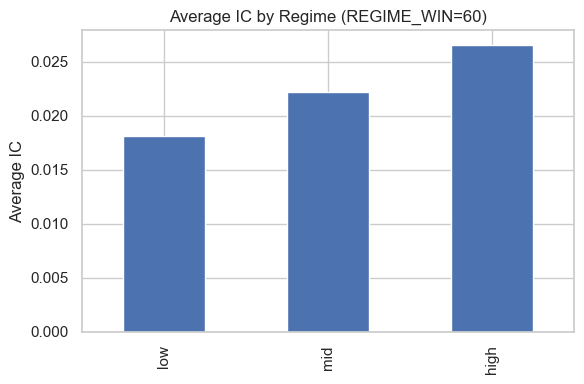

Average IC by regime — top 5 factors:


,low,mid,high
ROLL_MAX_M1_W5,0.1734,0.1778,0.1507
ZSCORE_M1_W120,0.1272,0.1717,0.1217
TECH_BB_POSITION_M1,0.1056,0.1104,0.0897
ROLL_STD_M1_W5,0.0891,0.0768,0.0299
ROLL_STD_M1_W10,0.0895,0.0966,-0.0090


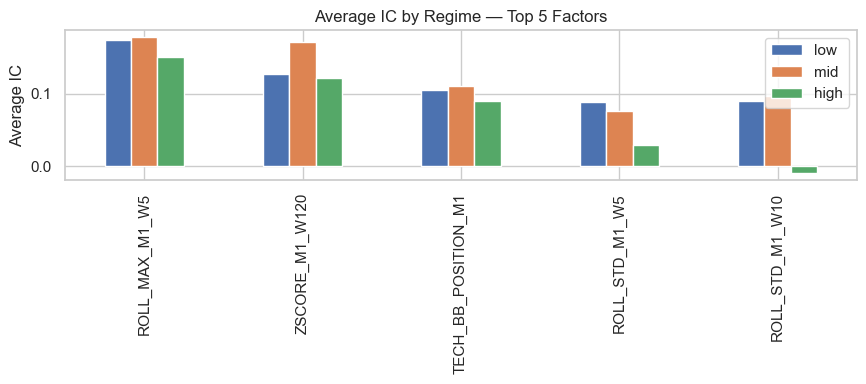

In [75]:
# === Regime IC (consistent with Rolling IC) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- knobs (reuse your global settings if already defined) ----
REGIME_WIN = REGIME_WIN if 'REGIME_WIN' in globals() else 60
REGIME_LOW_Q = REGIME_LOW_Q if 'REGIME_LOW_Q' in globals() else 0.33
REGIME_HIGH_Q = REGIME_HIGH_Q if 'REGIME_HIGH_Q' in globals() else 0.67
K = 5  # how many factors to show per-factor regime table
# ---------------------------------------------------------------

# If not, bail early with a friendly note.
if 'dfA' not in globals() or 'ic_df' not in globals() or ic_df.empty:
    print("Regime IC: Rolling IC 'ic_df' not found or empty. Run the Rolling IC cell first.")
else:
    # 1) Build volatility regimes from realized volatility of *returns* (historical, not forward)
    df_ret = (dfA[['date','returns']]
              .dropna()
              .sort_values('date')
              .drop_duplicates(subset=['date'])
              .set_index('date'))
    vol = df_ret['returns'].astype(float).rolling(REGIME_WIN).std()

    # Guard for insufficient variation
    if vol.dropna().empty or vol.fillna(0).nunique() <= 1:
        print("Regime analysis: insufficient variation in rolling volatility. "
              "Try reducing REGIME_WIN (e.g., to 20).")
    else:
        low_q  = vol.quantile(REGIME_LOW_Q)
        high_q = vol.quantile(REGIME_HIGH_Q)

        regime = pd.Series(index=vol.index, dtype='object')
        regime[vol <= low_q] = 'low'
        regime[(vol > low_q) & (vol < high_q)] = 'mid'
        regime[vol >= high_q] = 'high'

        # 2) Align regimes with IC dates
        #    Note: ic_df already has DatetimeIndex aligned to dfA['date'] in your Rolling IC block
        ic_df_sane = (ic_df.copy()
                      .apply(pd.to_numeric, errors='coerce')
                      .replace([np.inf, -np.inf], np.nan)
                      .clip(-1, 1))

        common_idx = ic_df_sane.index.intersection(regime.index)
        ic_aln = ic_df_sane.loc[common_idx]
        reg_aln = regime.loc[common_idx]

        if ic_aln.empty or reg_aln.dropna().empty:
            print("Regime analysis: no overlapping dates between IC and regime series.")
        else:
            # 3) Average IC across all factors by regime
            table = {}
            for rg in ['low','mid','high']:
                mask = (reg_aln == rg)
                if mask.any():
                    table[rg] = ic_aln.loc[mask].mean().mean()  # mean across dates, then factors
                else:
                    table[rg] = np.nan
            regime_ic_table = pd.Series(table, name='avg_IC').round(4).to_frame()

            print("Average IC by regime (across all factors):")
            display(regime_ic_table)

            plt.figure(figsize=(6,4))
            regime_ic_table['avg_IC'].plot(kind='bar')
            plt.title(f"Average IC by Regime (REGIME_WIN={REGIME_WIN})")
            plt.ylabel("Average IC")
            plt.tight_layout()
            plt.show()

            # 4) (Optional) Per-factor regime averages for the top-K IC factors overall
            # Reuse summary_ic from Rolling IC if available; otherwise compute quickly here
            if 'summary_ic' in globals():
                top_k_factors = summary_ic.index.tolist()[:K]
            else:
                mean_ic_overall = ic_aln.mean().sort_values(ascending=False)
                top_k_factors = mean_ic_overall.index.tolist()[:K]

            if top_k_factors:
                per_factor = []
                for f in top_k_factors:
                    vals = {}
                    for rg in ['low','mid','high']:
                        mask = (reg_aln == rg)
                        vals[rg] = ic_aln.loc[mask, f].mean()
                    per_factor.append(pd.Series(vals, name=f))
                per_factor_table = pd.DataFrame(per_factor).round(4)

                print(f"Average IC by regime — top {K} factors:")
                display(per_factor_table)

                ax = per_factor_table.plot(kind='bar', figsize=(9,4))
                ax.set_title(f"Average IC by Regime — Top {K} Factors")
                ax.set_ylabel("Average IC")
                plt.tight_layout()
                plt.show()


In [80]:
from sklearn.decomposition import PCA

base_cols = [c for c in ["date","instrument","returns", f"returns_fwd_{TARGET_HORIZON}"] if c in dfA.columns]

if MODE == 'full':
    df_model = df.copy()
    num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
    df_model[num_cols] = df_model[num_cols].replace([np.inf, -np.inf], np.nan)
    sort_cols = [c for c in ["instrument","date"] if c in df_model.columns]
    if sort_cols:
        df_model = df_model.sort_values(sort_cols).reset_index(drop=True)
    if "instrument" in df_model.columns:
        df_model[num_cols] = df_model.groupby("instrument")[num_cols].ffill().bfill()
    else:
        df_model[num_cols] = df_model[num_cols].ffill().bfill()
    drop_cols = [c for c in df_model.columns if df_model[c].isna().all() or df_model[c].nunique(dropna=True) <= 1]
    if drop_cols:
        df_model = df_model.drop(columns=drop_cols)
    cols_order = base_cols + [c for c in df_model.columns if c not in base_cols]
    df_model = df_model[cols_order]
else:
    if 'summary_ic' in globals() and not summary_ic.empty:
        top_ic_factors = summary_ic.index.tolist()[:TOP_IC_FACTOR_COUNT]
    else:
        top_ic_factors = (keepA if 'keepA' in globals() and keepA else analyzable)[:TOP_IC_FACTOR_COUNT]
    if len(analyzable) >= 2:
        X = dfA[analyzable].copy()
        X_filled = X.fillna(X.mean())
        pca = PCA(n_components=min(TOP_PC_COUNT, len(analyzable)))
        X_pca = pca.fit_transform(X_filled.values)
        pc_cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]
        df_pc = pd.DataFrame(X_pca, columns=pc_cols, index=X.index)
    else:
        df_pc = pd.DataFrame(index=dfA.index); pc_cols = []
    keep_cols = base_cols + top_ic_factors
    df_model = dfA[keep_cols].copy().join(df_pc, how="left")
    num_cols_hull = df_model.select_dtypes(include=[np.number]).columns.tolist()
    if "instrument" in df_model.columns:
        df_model = df_model.sort_values(["instrument","date"]).reset_index(drop=True)
        df_model[num_cols_hull] = df_model.groupby("instrument")[num_cols_hull].ffill().bfill()
    else:
        df_model[num_cols_hull] = df_model[num_cols_hull].ffill().bfill()

out_csv = Path("../outputs/factor_plus/model_ready.csv")
out_csv.parent.mkdir(parents=True, exist_ok=True)
df_model.to_csv(out_csv, index=False)
print("Saved:", out_csv, "| shape:", df_model.shape)
print("Columns (first 12):", list(df_model.columns)[:12])


Saved: ..\outputs\factor_plus\model_ready.csv | shape: (8990, 20)
Columns (first 12): ['date', 'instrument', 'returns', 'returns_fwd_1', 'ROLL_MAX_M1_W5', 'ZSCORE_M1_W120', 'TECH_BB_POSITION_M1', 'ROLL_STD_M1_W5', 'ROLL_STD_M1_W10', 'ROLL_MAX_M1_W120', 'ROLL_STD_M1_W20', 'ROLL_STD_M1_W60']
